# Programming language:

**Julia 1.10.4**

In [1]:
using Plots; pythonplot()
using Plots.Measures
using DelimitedFiles, DataFrames, CSV, JLD
using StatsBase    
using Combinatorics
using ProgressMeter
using GLM
using LaTeXStrings

# Load necessary data

In [2]:
## Repeats
dir_repeats="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/05.5.satellite.repeatmasker/output.modified_repeatmodeler_lib"

df_srp_sat=DataFrame(CSV.File("$(dir_repeats)/final_assembly.Papilio_bianor.fa.out.Simple_repeat_And_Satellite.coverage_w50ks50k.bed",header=false))
df_te=DataFrame(CSV.File("$(dir_repeats)/final_assembly.Papilio_bianor.fa.out.TE.coverage_w50ks50k.bed",header=false));


# Analysis of inferred ancestry haplotypes

## OrderMarker2 Output

In [3]:
dir_source = "/local/storage/tx84/Research/2022_HybridSterility/05.5_linkageMap.lepmap3_final_assembly"

cd(dir_source)

In [4]:
function get_marker_pos(chr::Int64,dir)
    
    pos = readdlm("$(dir)/call_data/data.call.with_pseudoGrandparents.fixedDiff_only.marker_positions/chr.$(chr).txt",String)
    
    return [parse(Int32,i[1]) for i in split.(pos,"*")][:,1]::Array{Int32,1}
    
end

get_marker_pos (generic function with 1 method)

In [5]:
function get_individual_alleles(x)
    
    Y = Bool[]
    for y in x
        z = split(y," ")[1]::SubString{String}
        z = parse.(Bool,split(z[1:Int(length(z)/2)],""))::BitVector
        Y = vcat(Y,z)
    end
    
    return Y::Vector{Bool}
    
end

get_individual_alleles (generic function with 1 method)

In [6]:
function get_recombination_breakpoints(h)
    
    δh = h[:,2:end] .- h[:,1:end-1]
    
    transitions = δh .!= 0
    
    return [findall(transitions[i,:]) for i in 1:size(transitions)[1]]
    
end

get_recombination_breakpoints (generic function with 1 method)

**Some problematic chromosomal termini to filter out:**

Chr3: 3' end: trim markers between 16.72Mb-end

Chr6: 5' end: trim markers between 0-0.3Mb

Chr10: 3' end: trim markers between 9.6Mb-end

Chr11: 3' end: trim markers between 14.6Mb-end

Chr20: 5' end: trim markers between 0-0.2Mb

Chr28: 5' end: trim markers between 0-0.4Mb

In [7]:
function get_filtered_interval(chr)

    if chr==3
        return [0,16.72]
    elseif chr==6
        return [0.3,+Inf]
    elseif chr==10
        return [0,9.6]
    elseif chr==11
        return [0,14.6]
    elseif chr==20
        return [0.2,+Inf]
    elseif chr==28
        return [0.4,+Inf]
    else
        return [0,+Inf]
    end
end

get_filtered_interval (generic function with 1 method)

## Inferring crossover patterns

In [11]:
f_0co_all = []
f_1co_all = []
f_2co_all = []

n_0re_all = []
n_1re_all = []
n_2re_all = []

for chr1 in 1:30

println(chr1)
    
family = "F01-F16"

if family == "F12-F16"
    f_idx = Array(12:16)
elseif family == "F01-F11"
    f_idx = Array(1:11)
else
    f_idx = Array(1:16)
end

marker_skips=2

interference = "0.001"
subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"

marker_idx_1 = []
male_cM_1 = []
hap1 = []

open("order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr1).txt","r") do io
    i=1
    for l in eachline(io)
        if string(l[1]) != "#"
            x = split(l,"\t")
            push!(marker_idx_1,x[1])
            push!(male_cM_1,x[2])
            push!(hap1,get_individual_alleles(x[f_idx .+ 4]))
            i = i+1
        end
    end
end

marker_idx_1 = parse.(Int32,marker_idx_1)
male_cM_1 = parse.(Float32,male_cM_1)
hap1 = hcat(hap1...)
hap1 = Float16.(hap1)

GC.gc()

x_left,x_right = get_filtered_interval(chr1) .* 1e6

marker_pos_1 = get_marker_pos(chr1,dir_source)

idx = 1:marker_skips:size(hap1)[2]
idx = idx[(marker_pos_1[marker_idx_1[idx]] .> x_left) .& (marker_pos_1[marker_idx_1[idx]] .< x_right)]
x_pos = marker_pos_1[marker_idx_1[idx]];

h1 = hap1[:,idx]
m_cM_1 = male_cM_1[idx] # the marey map coming from the 5'end

N=size(h1)[1]

breakpoints = get_recombination_breakpoints(h1)
n_recombinations = length.(breakpoints)

if any(n_recombinations .> 2)
    n_toomany = sum(n_recombinations .> 2)
    println("Chr$(chr1): More than 2 recombinations detected in $(n_toomany) samples!!")
end

n0 = sum(n_recombinations .== 0)
n1 = sum(n_recombinations .== 1)
n2 = sum(n_recombinations .== 2)

push!(n_0re_all,n0)
push!(n_1re_all,n1)
push!(n_2re_all,n2)

  
f_0co = (n0-n1+n2)/(n0+n1+n2)
f_1co = 2*(n1-2*n2)/(n0+n1+n2)
f_2co = 4*n2/(n0+n1+n2)
    
if any([f_0co,f_1co,f_2co].<0) & (n2 > 0)
    f_0co = 0
    f_1co = 1-2*n2/(n0+n2)
    f_2co = 2*n2/(n0+n2)
elseif any([f_0co,f_1co,f_2co].<0) & (n2==0)
    f_0co = max(0,(n0-n1)/(n0+n1))
    f_1co = min(1,2*n1/(n0+n1))
    f_2co = 0
end

if chr1==0
    push!(f_0co_all,NaN)
    push!(f_1co_all,NaN)
    push!(f_2co_all,NaN)
else 
    push!(f_0co_all,f_0co)
    push!(f_1co_all,f_1co)
    push!(f_2co_all,f_2co)
end

end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


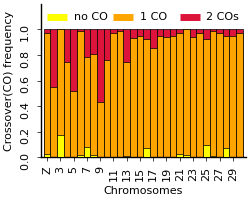

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [14]:
fig = plot(size=(250,200))

x = 1:30

dx = 0.5
bar!(fig,x,f_0co_all .+ f_1co_all .+ f_2co_all,
    xticks=(Array(1:2:29),vcat(["Z"],string.(Array(3:2:29)))),
    tickfontrotation=90,
    xlims=(0,31),
    grid=:off,
    color=:crimson,
    bar_width=1,
    linewidth=0.5,
    label="",
    xlabel="Chromosomes",
    ylabel="Crossover(CO) frequency",
    xguidefontsize=8,
    yguidefontsize=8,
    legend_background_color=false,
    legend=:topleft,
    # legend_column=3,
    tick_direction=:out,
    yticks=0:0.2:1,
    # marker=:square,
    ylims=(0,1.2),
)

bar!(fig,x,f_0co_all .+ f_1co_all,
    bar_width=1,
    linewidth=0.5,
    color=:orange,
    # marker=:circle,
    label="",
    )

bar!(fig,x,f_0co_all,
    bar_width=1,
    linewidth=0.5,
    color=:yellow,
    # marker=:diamond,
    label="",
    )

annotate!(fig,[(5,1.1,Plots.text("no CO",8,:left))])
annotate!(fig,[(15,1.1,Plots.text("1 CO",8,:left))])
annotate!(fig,[(25,1.1,Plots.text("2 COs",8,:left))])

plot!(fig,[1,4],[1.1,1.1],color=:yellow,linewidth=5,label="")
plot!(fig,[11,14],[1.1,1.1],color=:orange,linewidth=5,label="")
plot!(fig,[21,24],[1.1,1.1],color=:crimson,linewidth=5,label="")

# hline!(fig,[1],linewidth=1,linestyle=:dash,label="",linecolor=:black)

In [15]:
dir_output = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/InferredCOFreq"

savefig(fig,string(dir_output,"/CO_frequency.png"))
savefig(fig,string(dir_output,"/CO_frequency.pdf"))

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


"/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/InferredCOFreq/CO_frequency.pdf"

In [8]:
## saving source data

dir_output = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/InferredCOFreq"

open("$(dir_output)/CO_freq.csv","w") do f
    for i in 1:30
        if i == 1
            write(f,"Chromosome,FreqNoCO,Freq1CO,Freq2CO\n")
        end
        a = f_0co_all[i]
        b = f_1co_all[i]
        c = f_2co_all[i]
        if i<30
            write(f,"$(i),$(a),$(b),$(c)\n")
        else
            write(f,"Z,$(a),$(b),$(c)\n")
        end
        i = i+1
    end
end


#### Plot phased haplotypes wrt species ancestry

In [7]:
dir_source = "/local/storage/tx84/Research/2022_HybridSterility/05.5_linkageMap.lepmap3_final_assembly"


"/local/storage/tx84/Research/2022_HybridSterility/05.5_linkageMap.lepmap3_final_assembly"

1


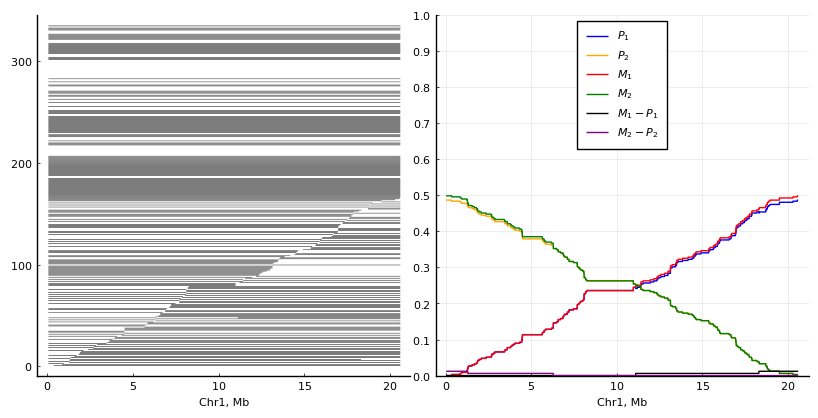

In [27]:
for chr1 in 1:1

    println(chr1)

    # chr1 = 28
    
    family = "F01-F16"
    
    if family == "F12-F16"
        f_idx = Array(12:16)
    elseif family == "F01-F11"
        f_idx = Array(1:11)
    else
        f_idx = Array(1:16)
    end
    
    marker_skips=10
    
    interference = "0.001"
    subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"
    
    marker_idx_1 = []
    male_cM_1 = []
    hap1 = []
    
    open("$(dir_source)/order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr1).txt","r") do io
        i=1
        for l in eachline(io)
            if string(l[1]) != "#"
                x = split(l,"\t")
                push!(marker_idx_1,x[1])
                push!(male_cM_1,x[2])
                push!(hap1,get_individual_alleles(x[f_idx .+ 4]))
                i = i+1
            end
        end
    end
    
    marker_idx_1 = parse.(Int32,marker_idx_1)
    male_cM_1 = parse.(Float32,male_cM_1)
    hap1 = hcat(hap1...)
        
    hap1 = Float16.(hap1)
    
    GC.gc()
    
    x_left,x_right = get_filtered_interval(chr1) .* 1e6
    
    marker_pos_1 = get_marker_pos(chr1,dir_source)
    
    idx = 1:marker_skips:size(hap1)[2]
    idx = idx[(marker_pos_1[marker_idx_1[idx]] .> x_left) .& (marker_pos_1[marker_idx_1[idx]] .< x_right)]
    x_pos = marker_pos_1[marker_idx_1[idx]];
    
    h1 = hap1[:,idx]
    m_cM_1 = male_cM_1[idx] # the marey map coming from the 5'end
    m_cM_2 = m_cM_1[end] .- m_cM_1 # the marey map coming from the 3'end
    
    N=size(h1)[1]
    
    ## remove below if necessary
    
    firstswitch=[]
    secondswitch=[]
    
    for i in 1:N
        h = h1[i,:] 
        δ = h[2:end] .- h[1:end-1]
        t = findall(δ .!= 0)
        if length(t) == 0 
            append!(firstswitch,NaN)
            append!(secondswitch,NaN)
        elseif length(t) == 1
            append!(firstswitch,t[1])
            append!(secondswitch,NaN)
        elseif length(t) >= 2
            append!(firstswitch,t[1])
            append!(secondswitch,t[2])
        end
    end
    
    perm_order = sortperm(firstswitch);
    
    recomb_p = []
    recomb_q = []
    # recomb_double = []
    for i in 1:size(h1)[2]
        append!(recomb_p,1 - sum(h1[:,1] .=== h1[:,i])/N)
        append!(recomb_q,1 - sum(h1[:,end] .=== h1[:,i])/N)
        # append!(recomb_double,sum((h1[:,1] .!= h1[:,i]) .& (h1[:,end] .!= h1[:,i]))/N)
    end
    # interference = recomb_p .* recomb_q - recomb_double;
    
        fig = plot(size=(800,400),layout=(1,2))
    for i in Array(1:size(perm_order)[1])
        plot!(fig,x_pos ./10^6,h1[perm_order[i],:]./2 .+ i,label="",
            seriestype=:steppre,
            linecolor=:white,
            fillcolor=:black,
            # xticks=0:1:(x_pos[end]/10^6),
            xlabel="Chr$(chr1), Mb",
            xguidefontsize=8,
            format=:png,
            dpi=300,
            grid=:off,
            fillrange=i,
                # xlims=(-Inf,1),
            subplot=1)
    end
    plot!(fig,x_pos ./10^6,recomb_p,
        ylims=(0,1),label=L"P_1",
        legend=:topleft,
        color=:blue,
        yticks=0:0.1:1,
        xlabel="Chr$(chr1), Mb",
        xguidefontsize=8,
        # xticks=0:1:(x_pos[end]/10^6),
            # xlims=(-Inf,1),
        subplot=2)
    plot!(fig,x_pos ./10^6,recomb_q,
        ylims=(0,1),label=L"P_2",
        legend=:top,
        color=:orange,
        yticks=0:0.1:1,
        # xticks=0:1:(x_pos[end]/10^6),
        subplot=2)
    
    plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100,
        ylims=(0,1),label=L"M_1",
        color=:red,
        subplot=2)
    
    plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100,
        ylims=(0,1),label=L"M_2",
        color=:green,
        subplot=2)
    
    plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100 .- recomb_p,
        ylims=(0,1),label=L"M_1-P_1",
        color=:black,
        subplot=2)
    
    plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100 .- recomb_q,
        ylims=(0,1),label=L"M_2-P_2",
        color=:purple,
        subplot=2)
    
    # save the figure as one loops over different chromosomes. They can be too large to display here
    
    dir_output = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning"
    
    savefig(fig,string(dir_output,"/chr$(chr1).png"))

end

# fig

In [24]:
chr1 = 9

idx = df_te[:,1] .== "scaffold_$(chr1)"

x_te = (df_te[idx,2] .+ df_te[idx,3])/(2*1e6)
y_te = df_te[idx,7]

271-element Vector{Float64}:
 0.79152
 0.73652
 0.68896
 0.55072
 0.57358
 0.5127
 0.5614
 0.56396
 0.46616
 0.4809
 0.585
 0.63638
 0.63866
 ⋮
 0.41236
 0.52064
 0.64124
 0.5125
 0.38582
 0.60398
 0.38456
 0.7069
 0.9213
 0.9824
 0.96634
 0.5519356

#### Examplary haplotype structures

9
15


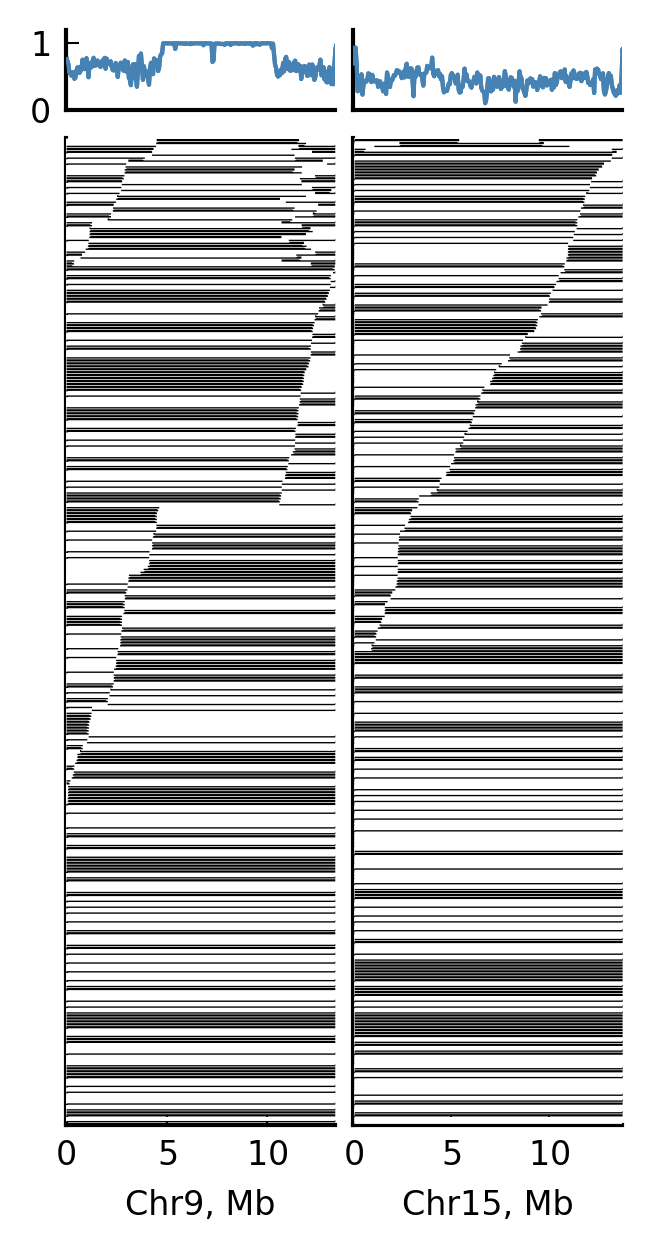

"/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning/examplary_haplotypes.chr9_15.png"

In [10]:
l = @layout[
    a{0.075h} b
    c d  
]

fig = plot(size=(200,400),layout=l)

s = 1

for chr1 in [9,15]

    idx = df_te[:,1] .== "scaffold_$(chr1)"

    x_te = (df_te[idx,2] .+ df_te[idx,3])/(2*1e6)
    y_te = df_te[idx,7]

    plot!(fig,x_te,y_te,
        xlims=(0,+Inf),
        ylims=(0,1),
        label="",
        linecolor=:steelblue,
        subplot=s
    )

    s = s+1

end

s = 3

for chr1 in [9,15]

    println(chr1)
    
    family = "F01-F16"
    
    if family == "F12-F16"
        f_idx = Array(12:16)
    elseif family == "F01-F11"
        f_idx = Array(1:11)
    else
        f_idx = Array(1:16)
    end
    
    marker_skips=1
    
    interference = "0.001"
    subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"
    
    marker_idx_1 = []
    male_cM_1 = []
    hap1 = []
    
    open("$(dir_source)/order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr1).txt","r") do io
        i=1
        for l in eachline(io)
            if string(l[1]) != "#"
                x = split(l,"\t")
                push!(marker_idx_1,x[1])
                push!(male_cM_1,x[2])
                push!(hap1,get_individual_alleles(x[f_idx .+ 4]))
                i = i+1
            end
        end
    end
    
    marker_idx_1 = parse.(Int32,marker_idx_1)
    male_cM_1 = parse.(Float32,male_cM_1)
    hap1 = hcat(hap1...)
        
    hap1 = Float16.(hap1)
    
    GC.gc()
    
    x_left,x_right = get_filtered_interval(chr1) .* 1e6
    
    marker_pos_1 = get_marker_pos(chr1,dir_source)
    
    idx = 1:marker_skips:size(hap1)[2]
    idx = idx[(marker_pos_1[marker_idx_1[idx]] .> x_left) .& (marker_pos_1[marker_idx_1[idx]] .< x_right)]
    x_pos = marker_pos_1[marker_idx_1[idx]];
    
    h1 = hap1[:,idx]
    m_cM_1 = male_cM_1[idx] # the marey map coming from the 5'end
    m_cM_2 = m_cM_1[end] .- m_cM_1 # the marey map coming from the 3'end
    
    N=size(h1)[1]
    
    ## remove below if necessary
    
    firstswitch=[]
    secondswitch=[]
    
    for i in 1:N
        h = h1[i,:] 
        δ = h[2:end] .- h[1:end-1]
        t = findall(δ .!= 0)
        if length(t) == 0 
            append!(firstswitch,NaN)
            append!(secondswitch,NaN)
        elseif length(t) == 1
            append!(firstswitch,t[1])
            append!(secondswitch,NaN)
        elseif length(t) >= 2
            append!(firstswitch,t[1])
            append!(secondswitch,t[2])
        end
    end
    
    idx_2break = findall((.! isnan.(secondswitch)) .& (.! isnan.(firstswitch)))
    idx_1break = findall(isnan.(secondswitch) .& (.! isnan.(firstswitch)))
    idx_0break = findall(isnan.(secondswitch) .& (isnan.(firstswitch)))
    
    perm_order = vcat(idx_0break,idx_1break[sortperm(firstswitch[idx_1break])],idx_2break[sortperm(firstswitch[idx_2break])])
    
    
    # perm_order = sortperm(firstswitch);
    
    # recomb_p = []
    # recomb_q = []
    # # recomb_double = []
    # for i in 1:size(h1)[2]
    #     append!(recomb_p,1 - sum(h1[:,1] .=== h1[:,i])/N)
    #     append!(recomb_q,1 - sum(h1[:,end] .=== h1[:,i])/N)
    #     # append!(recomb_double,sum((h1[:,1] .!= h1[:,i]) .& (h1[:,end] .!= h1[:,i]))/N)
    # end
    # interference = recomb_p .* recomb_q - recomb_double;
    
    for i in Array(1:size(perm_order)[1])
        plot!(fig,x_pos ./10^6,h1[perm_order[i],:]*0.75 .+ i,label="",
            seriestype=:steppre,
            linecolor=:white,
            fillcolor=:black,
            # xticks=0:1:(x_pos[end]/10^6),
            xlabel="Chr$(chr1), Mb",
            guidefontsize=8,
            format=:png,
            dpi=300,
            grid=:off,
            fillrange=i,
            xlims=(0,+Inf),
            xticks=[0,5,10],
            ylims=(0,336),
            yticks=[],
            ylabel="",
            subplot=s)
    end
    
    # plot!(fig,x_pos ./10^6,recomb_p,
    #     ylims=(0,1),label=L"P_1",
    #     legend=:topleft,
    #     color=:blue,
    #     yticks=0:0.1:1,
    #     xlabel="Chr$(chr1), Mb",
    #     xguidefontsize=8,
    #     # xticks=0:1:(x_pos[end]/10^6),
    #         # xlims=(-Inf,1),
    #     subplot=2)
    # plot!(fig,x_pos ./10^6,recomb_q,
    #     ylims=(0,1),label=L"P_2",
    #     legend=:top,
    #     color=:orange,
    #     yticks=0:0.1:1,
    #     # xticks=0:1:(x_pos[end]/10^6),
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100,
    #     ylims=(0,1),label=L"M_1",
    #     color=:red,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100,
    #     ylims=(0,1),label=L"M_2",
    #     color=:green,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100 .- recomb_p,
    #     ylims=(0,1),label=L"M_1-P_1",
    #     color=:black,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100 .- recomb_q,
    #     ylims=(0,1),label=L"M_2-P_2",
    #     color=:purple,
    #     subplot=2)

    idx = df_te[:,1] .== "scaffold_$(chr1)"

    x_te = (df_te[idx,2] .+ df_te[idx,3])/(2*1e6)
    y_te = df_te[idx,7]

    plot!(fig,x_te,y_te,
        xlims=(0,x_pos[end]/10^6),
        ylims=(0,1.2),
        yticks= s==3 ? ([0,1],["0","1"]) : [],
        grid=:off,
        label="",
        guidefontsize=8,
        xticks=[],
        linecolor=:steelblue,
        subplot=s-2
    )

    s = s+1
    
end

dir_out = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning"
savefig(fig,"$(dir_out)/examplary_haplotypes.chr9_15.pdf")
savefig(fig,"$(dir_out)/examplary_haplotypes.chr9_15.png")

In [26]:
dir_out = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning"
savefig(fig,"$(dir_out)/examplary_haplotypes.chr9_15.pdf")
savefig(fig,"$(dir_out)/examplary_haplotypes.chr9_15.png")

"/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning/examplary_haplotypes.chr5_15.png"

#### Plot double CO curves on bipartite chromosomes wrt TE blocks

In [12]:
dir_source = "/local/storage/tx84/Research/2022_HybridSterility/05.5_linkageMap.lepmap3_final_assembly"

dict_TE_block = Dict() ## major TE block boundaries measured in Mb
dict_TE_block["chr1,5"]=8325/1e3
dict_TE_block["chr1,3"]=10875/1e3
dict_TE_block["chr2,5"]=5682/1e3
dict_TE_block["chr2,3"]=13675/1e3
dict_TE_block["chr4,5"]=5330/1e3
dict_TE_block["chr4,3"]=9164/1e3
dict_TE_block["chr5,5"]=5400/1e3
dict_TE_block["chr5,3"]=7574/1e3
dict_TE_block["chr6,5"]=2425/1e3
dict_TE_block["chr6,3"]=6825/1e3
dict_TE_block["chr7,5"]=3730/1e3
dict_TE_block["chr7,3"]=6330/1e3
dict_TE_block["chr8,5"]=4280/1e3
dict_TE_block["chr8,3"]=8004/1e3
dict_TE_block["chr9,5"]=4762/1e3
dict_TE_block["chr9,3"]=10438/1e3
dict_TE_block["chr10,5"]=3745/1e3
dict_TE_block["chr10,3"]=6275/1e3
dict_TE_block["chr11,5"]=2352/1e3
dict_TE_block["chr11,3"]=5455/1e3
dict_TE_block["chr12,5"]=1704/1e3
dict_TE_block["chr12,3"]=2715/1e3
dict_TE_block["chr13,5"]=3773/1e3
dict_TE_block["chr13,3"]=5175/1e3

chrom_list = [2,4,5,7,8,9,10,13];

2
4
5
7
8
9
10
13


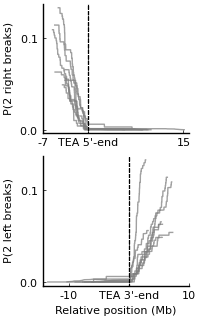

In [16]:
fig = plot(size=(200,320),layout=(2,1))

for chr1 in chrom_list

    println(chr1)

    # chr1 = 28
    
    family = "F01-F16"
    
    if family == "F12-F16"
        f_idx = Array(12:16)
    elseif family == "F01-F11"
        f_idx = Array(1:11)
    else
        f_idx = Array(1:16)
    end
    
    marker_skips=1
    
    interference = "0.001"
    subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"
    
    marker_idx_1 = []
    male_cM_1 = []
    hap1 = []
    
    open("$(dir_source)/order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr1).txt","r") do io
        i=1
        for l in eachline(io)
            if string(l[1]) != "#"
                x = split(l,"\t")
                push!(marker_idx_1,x[1])
                push!(male_cM_1,x[2])
                push!(hap1,get_individual_alleles(x[f_idx .+ 4]))
                i = i+1
            end
        end
    end
    
    marker_idx_1 = parse.(Int32,marker_idx_1)
    male_cM_1 = parse.(Float32,male_cM_1)
    hap1 = hcat(hap1...)
        
    hap1 = Float16.(hap1)
    
    GC.gc()
    
    x_left,x_right = get_filtered_interval(chr1) .* 1e6
    
    marker_pos_1 = get_marker_pos(chr1,dir_source)
    
    idx = 1:marker_skips:size(hap1)[2]
    idx = idx[(marker_pos_1[marker_idx_1[idx]] .> x_left) .& (marker_pos_1[marker_idx_1[idx]] .< x_right)]
    x_pos = marker_pos_1[marker_idx_1[idx]];
    
    h1 = hap1[:,idx]
    m_cM_1 = male_cM_1[idx] # the marey map coming from the 5'end
    m_cM_2 = m_cM_1[end] .- m_cM_1 # the marey map coming from the 3'end
    
    N=size(h1)[1]
    
    ## remove below if necessary
    
    firstswitch=[]
    secondswitch=[]
    
    for i in 1:N
        h = h1[i,:] 
        δ = h[2:end] .- h[1:end-1]
        t = findall(δ .!= 0)
        if length(t) == 0 
            append!(firstswitch,NaN)
            append!(secondswitch,NaN)
        elseif length(t) == 1
            append!(firstswitch,t[1])
            append!(secondswitch,NaN)
        elseif length(t) >= 2
            append!(firstswitch,t[1])
            append!(secondswitch,t[2])
        end
    end
    
    perm_order = sortperm(firstswitch);
    
    recomb_p = []
    recomb_q = []
    # recomb_double = []
    for i in 1:size(h1)[2]
        append!(recomb_p,1 - sum(h1[:,1] .=== h1[:,i])/N)
        append!(recomb_q,1 - sum(h1[:,end] .=== h1[:,i])/N)
        # append!(recomb_double,sum((h1[:,1] .!= h1[:,i]) .& (h1[:,end] .!= h1[:,i]))/N)
    end
    # interference = recomb_p .* recomb_q - recomb_double;

    plot!(fig,x_pos ./10^6 .- dict_TE_block["chr$(chr1),5"],((m_cM_2 .- m_cM_2[end])./100 .- recomb_q)./2,  
        # ylims=(0,0.2),
        # xlims=(0,10),
        xticks=([-7,0,15],["-7","TEA 5'-end","15"]),
        # yticks=[0,0.1,0.2,0.3,0.4],
        ylabel="P(2 right breaks)",
        label= chr1==2 ? "" : "",
        color=:gray,
        # format=:png,
        # dpi=300,
        grid=:off,
        # framestyle=:origin,
        linealpha=0.75,
        guidefontsize=8,
        tickfontsize=8,
        yticks=[0,0.1],
        legendfontsize=8,
        legend_foreground_color=:transparent,
        legend_background_color=:transparent,
        # xlabel="Relative position (Mb)",
        subplot=1
    )
    vline!(fig,[0],label="",linecolor=:black,linewidth=0.75,linestyle=:dash,subplot=1)
    
    plot!(fig,x_pos ./10^6 .- dict_TE_block["chr$(chr1),3"],((m_cM_1 .- m_cM_1[1])./100 .- recomb_p)./2,  
        label= chr1==2 ? "" : "",
        ylabel="P(2 left breaks)",
        xticks=([-10,0,10],["-10","TEA 3'-end","10"]),
        color=:gray,
        # format=:png,
        # dpi=300,
        grid=:off,
        # framestyle=:origin,
        linealpha=0.75,
        guidefontsize=8,
        tickfontsize=8,
        yticks=[0,0.1],
        legendfontsize=8,
        legend_foreground_color=:transparent,
        legend_background_color=:transparent,
        xlabel="Relative position (Mb)",
        subplot=2
    )
    vline!(fig,[0],label="",linecolor=:black,linewidth=0.75,linestyle=:dash,subplot=2)

    # plot!(fig,x_pos ./10^6,recomb_p,
    #     ylims=(0,1),label=L"P_1",
    #     legend=:topleft,
    #     color=:blue,
    #     yticks=0:0.1:1,
    #     xlabel="Chr$(chr1), Mb",
    #     xguidefontsize=8,
    #     # xticks=0:1:(x_pos[end]/10^6),
    #         # xlims=(-Inf,1),
    #     subplot=2)
    # plot!(fig,x_pos ./10^6,recomb_q,
    #     ylims=(0,1),label=L"P_2",
    #     legend=:top,
    #     color=:orange,
    #     yticks=0:0.1:1,
    #     # xticks=0:1:(x_pos[end]/10^6),
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100,
    #     ylims=(0,1),label=L"M_1",
    #     color=:red,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100,
    #     ylims=(0,1),label=L"M_2",
    #     color=:green,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_1 .- m_cM_1[1])./100 .- recomb_p,
    #     ylims=(0,1),label=L"M_1-P_1",
    #     color=:black,
    #     subplot=2)
    
    # plot!(fig,x_pos ./10^6,(m_cM_2 .- m_cM_2[end])./100 .- recomb_q,
    #     ylims=(0,1),label=L"M_2-P_2",
    #     color=:purple,
    #     subplot=2)

end

fig

In [17]:
dir_out = "/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning"

savefig(fig,"$(dir_out)/MP_curves.multichromosomes.png")
savefig(fig,"$(dir_out)/MP_curves.multichromosomes.pdf")

"/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/COPatterning/MP_curves.multichromosomes.pdf"

##### Example curves to test if interference reduction is chromosome-wide or bipartite

In [44]:
dict_pos_switch = Dict()

pos_end=Dict()

for chr1 in chrom_list

    println(chr1)
    
    # chr1 = 28
    
    family = "F01-F16"
    
    if family == "F12-F16"
        f_idx = Array(12:16)
    elseif family == "F01-F11"
        f_idx = Array(1:11)
    else
        f_idx = Array(1:16)
    end
    
    marker_skips=1
    
    interference = "0.001"
    subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"
    
    marker_idx_1 = []
    male_cM_1 = []
    hap1 = []
    
    open("$(dir_source)/order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr1).txt","r") do io
        i=1
        for l in eachline(io)
            if string(l[1]) != "#"
                x = split(l,"\t")
                push!(marker_idx_1,x[1])
                push!(male_cM_1,x[2])
                push!(hap1,get_individual_alleles(x[f_idx .+ 4]))
                i = i+1
            end
        end
    end
    
    marker_idx_1 = parse.(Int32,marker_idx_1)
    male_cM_1 = parse.(Float32,male_cM_1)
    hap1 = hcat(hap1...)
        
    hap1 = Float16.(hap1)
    
    GC.gc()
    
    x_left,x_right = get_filtered_interval(chr1) .* 1e6
    
    marker_pos_1 = get_marker_pos(chr1,dir_source)
    
    idx = 1:marker_skips:size(hap1)[2]
    idx = idx[(marker_pos_1[marker_idx_1[idx]] .> x_left) .& (marker_pos_1[marker_idx_1[idx]] .< x_right)]
    x_pos = marker_pos_1[marker_idx_1[idx]];
    pos_end["chr$(chr1)"] = x_pos[end]/1e6
    
    h1 = hap1[:,idx]
    m_cM_1 = male_cM_1[idx] # the marey map coming from the 5'end
    m_cM_2 = m_cM_1[end] .- m_cM_1 # the marey map coming from the 3'end
    
    N=size(h1)[1]
    
    ## remove below if necessary
    
    firstswitch=[]
    secondswitch=[]
    
    for i in 1:N
        h = h1[i,:] 
        δ = h[2:end] .- h[1:end-1]
        t = findall(δ .!= 0)
        if length(t) == 0 
            append!(firstswitch,NaN)
            append!(secondswitch,NaN)
        elseif length(t) == 1
            append!(firstswitch,t[1])
            append!(secondswitch,NaN)
        elseif length(t) >= 2
            append!(firstswitch,t[1])
            append!(secondswitch,t[2])
        end
    end
    
    perm_order = sortperm(firstswitch);
    
    recomb_p = []
    recomb_q = []
    # recomb_double = []
    for i in 1:size(h1)[2]
        append!(recomb_p,1 - sum(h1[:,1] .=== h1[:,i])/N)
        append!(recomb_q,1 - sum(h1[:,end] .=== h1[:,i])/N)
        # append!(recomb_double,sum((h1[:,1] .!= h1[:,i]) .& (h1[:,end] .!= h1[:,i]))/N)
    end
    # interference = recomb_double ./ (recomb_p .* recomb_q);

    idx = .! isnan.(secondswitch)
    dict_pos_switch["chr$(chr1),pos_1s"] = (x_pos[firstswitch[idx]] .+ x_pos[firstswitch[idx].+1])./2e6
    dict_pos_switch["chr$(chr1),pos_2s"] = (x_pos[secondswitch[idx]] .+ x_pos[secondswitch[idx].+1])./2e6

end

2
4
5
7
8
9
10
13


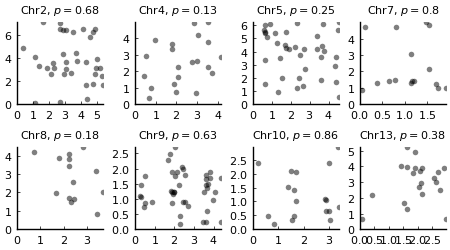

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [120]:
fig = plot(size=(450,250),layout=(2,4))

i = 1
for chr1 in chrom_list

    d1 = dict_TE_block["chr$(chr1),5"] .- dict_pos_switch["chr$(chr1),pos_1s"]
    d2 = dict_pos_switch["chr$(chr1),pos_2s"].-dict_TE_block["chr$(chr1),3"]
    idx = (d1.>=0) .& (d2.>=0)
    d1 = d1[idx]
    d2 = d2[idx]

    ols = lm(@formula(Y ~ X),DataFrame(X=d1,Y=d2))
    pval = round(coeftable(ols).cols[4][2],sigdigits=2)
    
    scatter!(fig,d1,d2,
        label="",
        title=string("Chr$(chr1), ",L"p=",string(pval)),
        titlefontsize=8,
        markerstrokewidth=0,
        markercolor=:black,
        markeralpha=0.5,
        subplot=i,
        grid=:off,
        xlims=(0,+Inf),
        ylims=(0,+Inf),
    )
    
    
    i = i+1
end

fig

#### Converting phased outputs to species ancestry

In [13]:
for chr in 1:30

family = "F01-F16"

if family == "F12-F16"
    f_idx = Array(12:16)
elseif family == "F01-F11"
    f_idx = Array(1:11)
else
    f_idx = Array(1:16)
end

interference = "0.001"
subdir = "impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference)"

marker_idx = []
male_cM = []
hap = []

open("order_markers_results/$(subdir)/impute.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.$(interference).$(family).chr.$(chr).txt","r") do io
    i=1
    for l in eachline(io)
        if string(l[1]) != "#"
            x = split(l,"\t")
            push!(marker_idx,x[1])
            push!(male_cM,x[2])
            push!(hap,get_individual_alleles(x[f_idx .+ 4]))
            i = i+1
        end
    end
end

marker_idx = parse.(Int32,marker_idx)
male_cM = parse.(Float32,male_cM)
hap = Int8.(hcat(hap...))

# bianor: 0; dehaanii: 1

ancestry = vcat(1 .- hap[1:162,:],hap[163:335,:])

dir_out = "/local/storage/tx84/Research/2022_HybridSterility/05.5_linkageMap.lepmap3_final_assembly/order_markers_results"
file_name = "/$(subdir)/ancestry.paternal.B0D1.with_pseudoGrandparents.fixedDiff_only.grandparentPhase.1.recombination1.0.001.interference1.0.001.$(family).chr.$(chr).txt"
open(string(dir_out,file_name),"w") do file
    for i in 1:335
        write(file,string(join(string.(ancestry[i,:])," "),"\n"))
    end
end
    
end